# Part 2: Modeling & Evaluation

This notebook performs ridge regression modeling and evaluation on fMRI brain response data using embeddings generated by our custom pre-trained encoder (trained via masked language modeling in Part 1). Building on the methods used in Lab 3.1, we aim to assess the effectiveness of the custom embeddings in predicting voxel-level BOLD responses.

## Objectives
- Predict voxel-wise fMRI responses using delay-embedded features generated from the custom encoder.
- Apply ridge regression modeling following the same procedures as Lab 3.1 to ensure comparability.
- Evaluate model performance using the following metrics:
    - Mean test correlation coefficient (CC)
    - Median test CC
    - Top 1 percentile CC
    - Top 5 percentile CC
- Analyze:
    - The distribution of voxel-level CCs for insights into spatial variability.
    - Stability of model performance across different subjects and stories under the PCS (Predictability, Computability, Stability) framework.

## Files Used
This notebook assumes the following inputs:
- `../data/X_lagged_mlm.joblib`: Preprocessed and temporally lagged embeddings generated from our MLM encoder.
- Brain response data (`.npy` files) located at:

`../../tmp_ondemand_ocean_mth240012p_symlink/shared/data/`

- Ridge regression utilities from the provided `ridge_utils/` directory.

In [1]:
# import required package

import numpy as np
import joblib
import pickle
from pathlib import Path
from sklearn.model_selection import train_test_split
import sys
import importlib.util
import os

In [2]:
"""
Loads embedding features, brain response data, and ridge regression utilities for modeling.

- Loads delay-embedded features from file.
- Loads fMRI response data for Subject 2 and Subject 3.
- Dynamically loads ridge regression functions from the provided utilities.
- Prepares input dictionaries for subsequent regression analysis.
"""

embedding_dir = Path("data")
subject2_dir = Path("tmp_ondemand_ocean_mth240012p_symlink/shared/data/subject2")
subject3_dir = Path("tmp_ondemand_ocean_mth240012p_symlink/shared/data/subject3")
ridge_py_path = Path("ridge.py")
ridge_utils_dir = Path("ridge_utils") 

sys.path.append(str(ridge_utils_dir))

spec = importlib.util.spec_from_file_location("ridge", ridge_py_path)
ridge = importlib.util.module_from_spec(spec)
sys.modules["ridge"] = ridge
spec.loader.exec_module(ridge)
bootstrap_ridge = ridge.bootstrap_ridge

X = joblib.load("X_lagged_mlm.joblib")
X_dict = {"Self":X}

def load_subject_data(subject_dir):
    return {f.stem: np.load(f) for f in subject_dir.glob("*.npy")}

Y_subject2 = load_subject_data(subject2_dir)
Y_subject3 = load_subject_data(subject3_dir)

In [4]:
"""
Performs ridge regression modeling and evaluation across embeddings, subjects, and stories.

- Standardizes (z-scores) the input features and brain responses.
- Splits data into training and testing sets (80/20 split).
- Performs bootstrap ridge regression with cross-validation over a grid of alpha values.
- Accumulates voxel-level correlation coefficients (CCs) across all tasks.
- Records mean CCs for each (embedding type, subject, story) triplet into a results DataFrame.
"""

from time import time
import pandas as pd

results = []
total_tasks = sum(len(X_dict[x_key]) for x_key in X_dict for _ in [0, 1])
task_counter = 0

all_corrs = []
results = []

# Standardize features by removing the mean and scaling to unit variance (z-score normalization)
def zs(v):
    std = v.std(axis=0)
    std[std == 0] = 1
    return (v - v.mean(axis=0)) / std

# Iterate over each embedding type (only one in this case: "Self")
for x_key, x_data in X_dict.items():

    # Iterate over each subject's brain response data
    for subj_key, y_data in [("subj2", Y_subject2), ("subj3", Y_subject3)]:

        # Find the set of shared stories between the embeddings and the fMRI data
        shared_stories = sorted(list(set(x_data.keys()) & set(y_data.keys())))

        # Process each shared story individually
        for story in shared_stories:  
            print(f"\n[Running] {x_key} - {subj_key} - {story}")
            X = x_data[story]
            Y = y_data[story]

            if X.shape[0] != Y.shape[0]:
                print(f"  [Skip] Mismatch in shape: X={X.shape}, Y={Y.shape}")
                continue

            try:
                X_z = zs(X)
                Y_z = zs(Y)
                X_train, X_test, Y_train, Y_test = train_test_split(X_z, Y_z, test_size=0.2, random_state=42)
                alphas = np.logspace(0, 3, 20)
                start_time = time()
                wt, corrs, valalphas, _, _ = bootstrap_ridge(
                    X_train, Y_train, X_test, Y_test,
                    alphas=alphas, nboots=10, chunklen=10, nchunks=2,
                    return_wt=True
                )
                elapsed = time() - start_time
                print(f"  [Done] Mean CC={np.mean(corrs):.3f}, Time={elapsed:.1f}s")

                all_corrs.extend(corrs)  # accumulate all voxel-level CCs
                results.append((x_key, subj_key, story, float(np.mean(corrs))))

            except Exception as e:
                # Handle any errors during processing
                print(f"  [Error] {story}: {e}")

df = pd.DataFrame(results, columns=["X_type", "subject", "story", "mean_cc"])


[Running] Self - subj2 - adollshouse
  [Done] Mean CC=0.028, Time=8.1s

[Running] Self - subj2 - adventuresinsayingyes
  [Done] Mean CC=0.011, Time=9.5s

[Running] Self - subj2 - afatherscover
  [Done] Mean CC=0.029, Time=8.5s

[Running] Self - subj2 - afearstrippedbare
  [Done] Mean CC=-0.002, Time=10.2s

[Running] Self - subj2 - againstthewind
  [Done] Mean CC=0.038, Time=7.3s

[Running] Self - subj2 - alternateithicatom
  [Done] Mean CC=0.004, Time=9.0s

[Running] Self - subj2 - avatar
  [Done] Mean CC=0.043, Time=9.2s

[Running] Self - subj2 - backsideofthestorm
  [Done] Mean CC=-0.004, Time=9.1s

[Running] Self - subj2 - becomingindian
  [Done] Mean CC=0.035, Time=9.3s

[Running] Self - subj2 - beneaththemushroomcloud
  [Done] Mean CC=0.027, Time=8.8s

[Running] Self - subj2 - birthofanation
  [Done] Mean CC=0.027, Time=8.0s

[Running] Self - subj2 - bluehope
  [Done] Mean CC=0.004, Time=9.7s

[Running] Self - subj2 - breakingupintheageofgoogle
  [Done] Mean CC=0.024, Time=10.4s


/jet/home/xchen26/.conda/envs/env_214/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


  [Done] Mean CC=0.043, Time=9.9s

[Running] Self - subj2 - catfishingstrangerstofindmyself
  [Done] Mean CC=0.011, Time=8.6s

[Running] Self - subj2 - cautioneating
  [Done] Mean CC=0.027, Time=8.2s

[Running] Self - subj2 - christmas1940
  [Done] Mean CC=0.043, Time=7.8s

[Running] Self - subj2 - cocoonoflove
  [Done] Mean CC=0.013, Time=9.8s

[Running] Self - subj2 - comingofageondeathrow
  [Done] Mean CC=0.035, Time=9.2s

[Running] Self - subj2 - escapingfromadirediagnosis
  [Done] Mean CC=0.034, Time=9.0s

[Running] Self - subj2 - exorcism
  [Done] Mean CC=0.055, Time=10.4s

[Running] Self - subj2 - eyespy
  [Done] Mean CC=0.026, Time=9.4s

[Running] Self - subj2 - findingmyownrescuer
  [Done] Mean CC=0.027, Time=9.2s

[Running] Self - subj2 - firetestforlove
  [Done] Mean CC=0.036, Time=8.7s

[Running] Self - subj2 - food
  [Done] Mean CC=0.027, Time=9.2s

[Running] Self - subj2 - forgettingfear
  [Done] Mean CC=0.014, Time=7.9s

[Running] Self - subj2 - fromboyhoodtofatherhood
 

In [5]:
#Summary 
print("Mean CC:", np.mean(all_corrs))
print("Median CC:", np.median(all_corrs))
print("Top 5% Quantile:", np.quantile(all_corrs, 0.95))
print("Top 1% Quantile:", np.quantile(all_corrs, 0.99))

Mean CC: 0.024756867253600965
Median CC: 0.02348970085563555
Top 5% Quantile: 0.24477648936995067
Top 1% Quantile: 0.3442586110095701


In [7]:
embedding = df.groupby("X_type")["mean_cc"].mean().idxmax()
print(f"\n Embedding: {embedding}")


 Embedding: Self


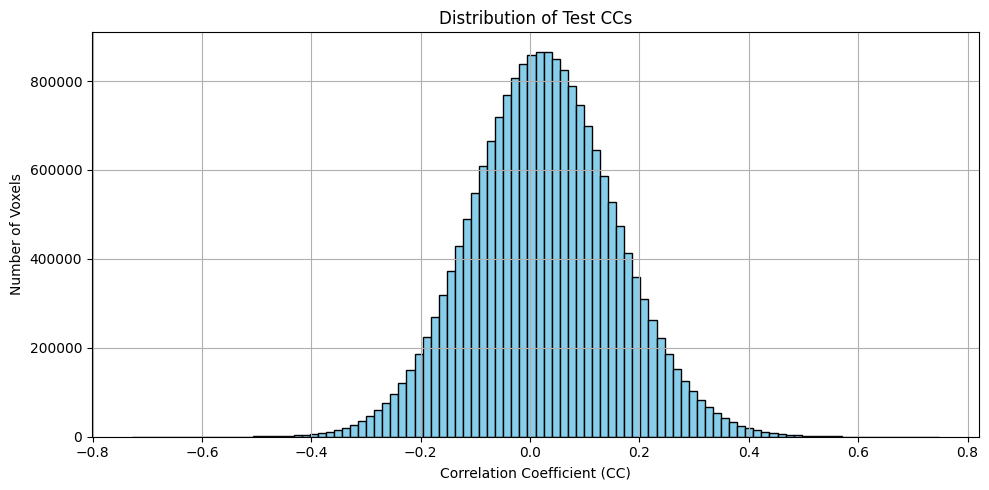

In [8]:
# Make Distribution of Test CCs
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(all_corrs, bins=100, color='skyblue', edgecolor='black')
plt.title(f"Distribution of Test CCs")
plt.xlabel("Correlation Coefficient (CC)")
plt.ylabel("Number of Voxels")
plt.grid(True)
plt.tight_layout()
plt.savefig("distribution.png", dpi=300)
plt.show()

In [10]:
print("\n Stability Analysis: Comparing Subject2 vs Subject3")
for emb in df["X_type"].unique():
    subj2_mean = df[(df["X_type"] == emb) & (df["subject"] == "subj2")]["mean_cc"].mean()
    subj3_mean = df[(df["X_type"] == emb) & (df["subject"] == "subj3")]["mean_cc"].mean()
    print(f"{emb}: Subject2 mean={subj2_mean:.4f}, Subject3 mean={subj3_mean:.4f}")


 Stability Analysis: Comparing Subject2 vs Subject3
Self: Subject2 mean=0.0241, Subject3 mean=0.0254
